# DrugEx ROCS Quick Start: Shape-Based RL

**Minimal tutorial showing the RL training loop for CCR2 ligand design with RDKit ROCS**

## Prerequisites

1. Run fine-tuning first: `python prepare_models.py`
2. See `tutorial/` for basic DrugEx concepts (pretrain, finetune, RL)

## What This Does

- Trains an RL model to generate CCR2 ligands optimized for shape similarity (ROCS) and synthetic accessibility
- Uses predefined settings from `config.py`
- Saves trained model for molecule generation

In [1]:
# Imports
import time
import pandas as pd
import matplotlib.pyplot as plt
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
from config import setup_rl_rdkit, RL_EPOCHS, RL_EPSILON, RL_N_SAMPLES

In [2]:
# Setup (loads models, creates environment with predefined settings)
agent, mutate, env, output_dir = setup_rl_rdkit()

Vocabulary loaded: 95 tokens
Environment created with RDKit ROCS + SA scorers
Agent loaded from pretrained model
Mutate network loaded from fine-tuned model

Setup complete! Using device: cuda:0


In [3]:
# Create RL explorer
explorer = SequenceExplorer(
    agent=agent,
    env=env,
    mutate=mutate,
    epsilon=RL_EPSILON,
    n_samples=RL_N_SAMPLES,
)

print(f"RL Config: {RL_EPOCHS} epochs, epsilon={RL_EPSILON}, samples={RL_N_SAMPLES}")

RL Config: 10 epochs, epsilon=0.2, samples=5000


In [4]:
# Train RL model
output_base = output_dir / 'CCR2_rdkit_reinforced'
monitor = FileMonitor(str(output_base), save_smiles=True, reset_directory=True)

start = time.time()
explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
monitor.close()

print(f"\nCompleted in {(time.time()-start)/60:.1f} minutes")
print(f"Model saved: {output_base}.pkg")

Removing CCR2_rdkit_reinforced_fit.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced_fit.log from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced_smiles.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced.pkg from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/advanced/rocs/rl_runs_demo/rdkit_rl


Fitting SMILES RNN explorer:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/40 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/40 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/39 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/39 [00:00<?, ?it/s]

KeyboardInterrupt: Embedding cancelled

In [ ]:
df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')
df


,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.94,0.94,0.00,0.848,0.841,0.169,-1
1,2,0.94,0.94,0.02,0.875,0.869,0.168,2
2,3,0.88,0.88,0.00,0.871,0.866,0.126,2
3,4,0.96,0.96,0.00,0.873,0.863,0.141,2
4,5,0.98,0.98,0.00,0.876,0.867,0.105,2
5,6,0.98,0.98,0.00,0.888,0.883,0.102,2
6,7,0.98,0.98,0.00,0.895,0.890,0.098,2
7,8,0.92,0.92,0.04,0.884,0.876,0.100,8
8,9,0.94,0.94,0.00,0.906,0.902,0.096,8
9,10,0.92,0.92,0.00,0.887,0.881,0.093,8


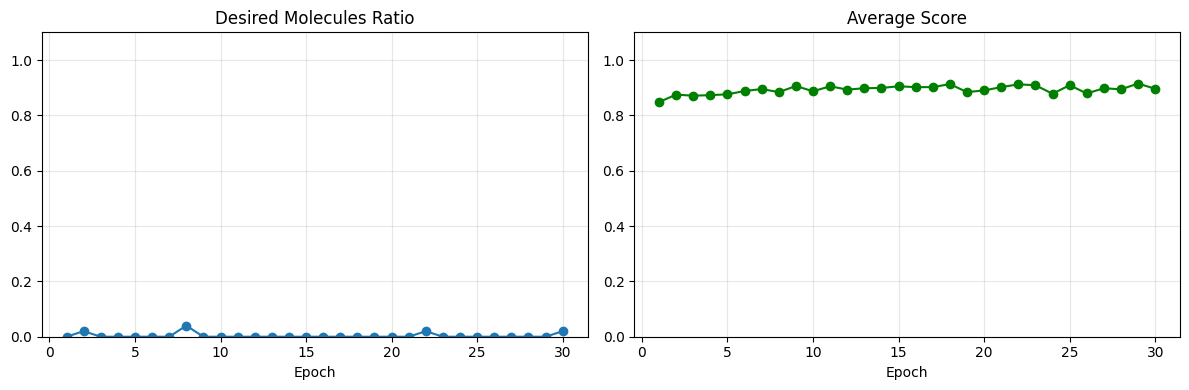


Final 5 epochs:
    Epoch  desired_ratio  avg_amean
25     26           0.00      0.879
26     27           0.00      0.898
27     28           0.00      0.894
28     29           0.00      0.915
29     30           0.02      0.896


In [ ]:
# Plot training progress
df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(df['Epoch'], df['desired_ratio'], marker='o')
ax1.set_title('Desired Molecules Ratio')
ax1.set_xlabel('Epoch')
ax1.set_ylim(0, 1.1)
ax1.grid(alpha=0.3)

ax2.plot(df['Epoch'], df['avg_amean'], marker='o', color='green')
ax2.set_title('Average Score')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1.1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal 5 epochs:")
print(df[['Epoch', 'desired_ratio', 'avg_amean']].tail())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')

df.plot(x='Epoch', y=['desired_ratio', 'avg_amean'], subplots=True, layout=(1,2),
        figsize=(12,4), marker='o', ylim=(0,1.1), grid=True, legend=False, title=['Desired Molecules Ratio','Average Score'])

plt.tight_layout()
plt.show()

print("\nFinal 5 epochs:\n", df[['Epoch','desired_ratio','avg_amean']].tail())


KeyError: 'epoch'

## Next Steps

### Generate Molecules
```bash
python generate_molecules.py
```

### Try Other Backends
- CDPKit: `python run_cdpkit_rocs.py`
- OpenEye: `python run_openeye_rocs.py`

### Customize
Edit `config.py` to change:
- RL parameters (epochs, epsilon, samples)
- Conformer settings (max_conformers, max_isomers)
- Reference ligands (CCR2_SDF path)